In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
# 1. Gerando os dados sintéticos
np.random.seed(42)
X = np.random.rand(100, 1) * 10 # Valores entre 0 e 10
y = 10 + 2 * X + 3 * X**2 + np.random.normal(0, 10, size=(100, 1)) #Relação não-linear com ruído

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Modelo de grau 1:
  MSE Treino: 1449.34, MSE Teste: 851.96
  R² Treino: 0.86, R² Teste: 0.91

Modelo de grau 2:
  MSE Treino: 947.07, MSE Teste: 599.79
  R² Treino: 0.91, R² Teste: 0.94

Modelo de grau 10:
  MSE Treino: 891.16, MSE Teste: 708.21
  R² Treino: 0.92, R² Teste: 0.93



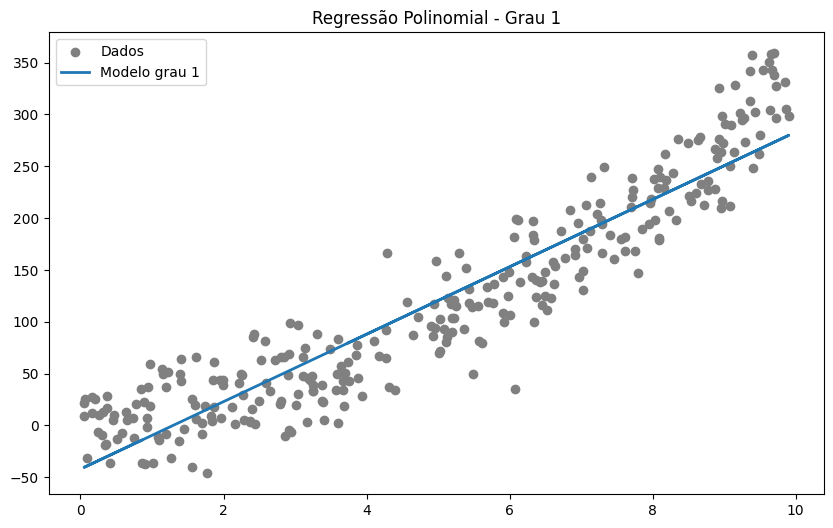

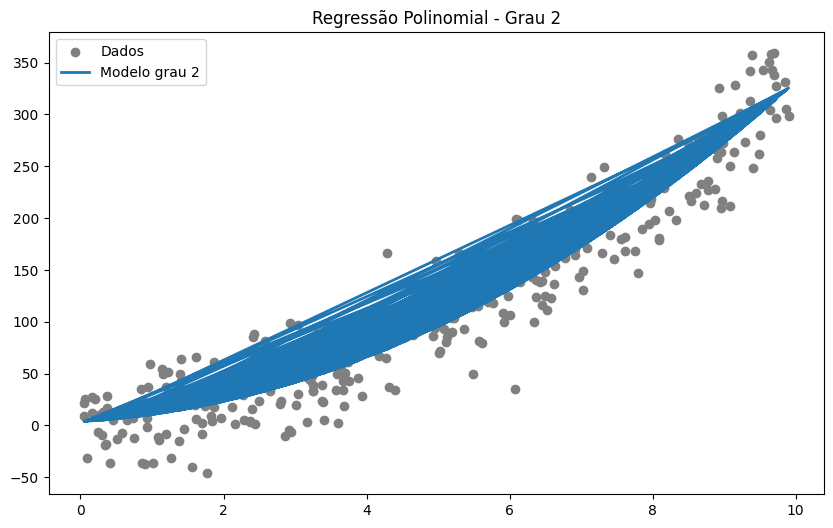

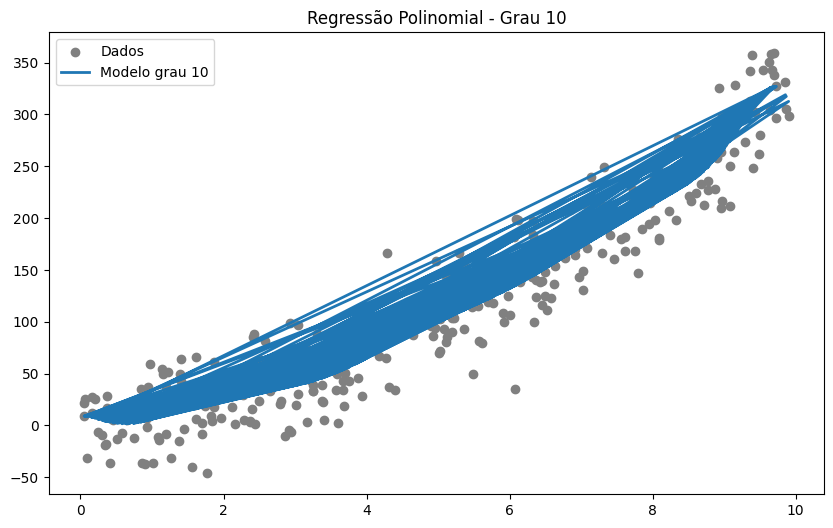

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Geração de Dados Sintéticos
np.random.seed(42)
X = np.random.rand(300, 1) * 10  # Valores entre 0 e 10
y = 10 + 2 * X + 3 * X**2 + np.random.normal(0, 30, size=(300, 1))  # Relação não-linear com ruído

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Função para treinar e avaliar modelos
def treinar_avaliar(grau):
    # Criando as features polinomiais
    poly = PolynomialFeatures(degree=grau)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    # Ajustando o modelo
    modelo = LinearRegression()
    modelo.fit(X_poly_train, y_train)

    # Fazendo previsões
    y_pred_train = modelo.predict(X_poly_train)
    y_pred_test = modelo.predict(X_poly_test)

    # Calculando métricas
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    return mse_train, mse_test, r2_train, r2_test

# Treinando modelos de diferentes complexidades
graus = [1, 2, 10]
resultados = []

for grau in graus:
    mse_train, mse_test, r2_train, r2_test = treinar_avaliar(grau)
    resultados.append((grau, mse_train, mse_test, r2_train, r2_test))
    print(f"Modelo de grau {grau}:")
    print(f"  MSE Treino: {mse_train:.2f}, MSE Teste: {mse_test:.2f}")
    print(f"  R² Treino: {r2_train:.2f}, R² Teste: {r2_test:.2f}\n")

# Visualização
for grau in graus:
    poly = PolynomialFeatures(degree=grau)
    X_poly = poly.fit_transform(X)
    modelo = LinearRegression().fit(X_poly, y)
    y_pred = modelo.predict(X_poly)

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, label="Dados", color="gray")
    plt.plot(X, y_pred, label=f"Modelo grau {grau}", linewidth=2)
    plt.title(f"Regressão Polinomial - Grau {grau}")
    plt.legend()
    plt.show()


Degree 1:
  Train MSE: 672.42, R²: 0.92
  Test MSE: 549.96662, R²: 0.94230
Degree 2:
  Train MSE: 81.47, R²: 0.99
  Test MSE: 63.58406, R²: 0.99333
Degree 3:
  Train MSE: 80.75, R²: 0.99
  Test MSE: 64.20493, R²: 0.99326
Degree 4:
  Train MSE: 78.75, R²: 0.99
  Test MSE: 68.91277, R²: 0.99277
Degree 5:
  Train MSE: 78.59, R²: 0.99
  Test MSE: 68.59366, R²: 0.99280
Degree 6:
  Train MSE: 78.24, R²: 0.99
  Test MSE: 70.29393, R²: 0.99263
Degree 7:
  Train MSE: 78.19, R²: 0.99
  Test MSE: 70.98400, R²: 0.99255
Degree 8:
  Train MSE: 78.18, R²: 0.99
  Test MSE: 71.06718, R²: 0.99254
Degree 9:
  Train MSE: 77.85, R²: 0.99
  Test MSE: 69.07389, R²: 0.99275
Degree 10:
  Train MSE: 77.04, R²: 0.99
  Test MSE: 66.12037, R²: 0.99306


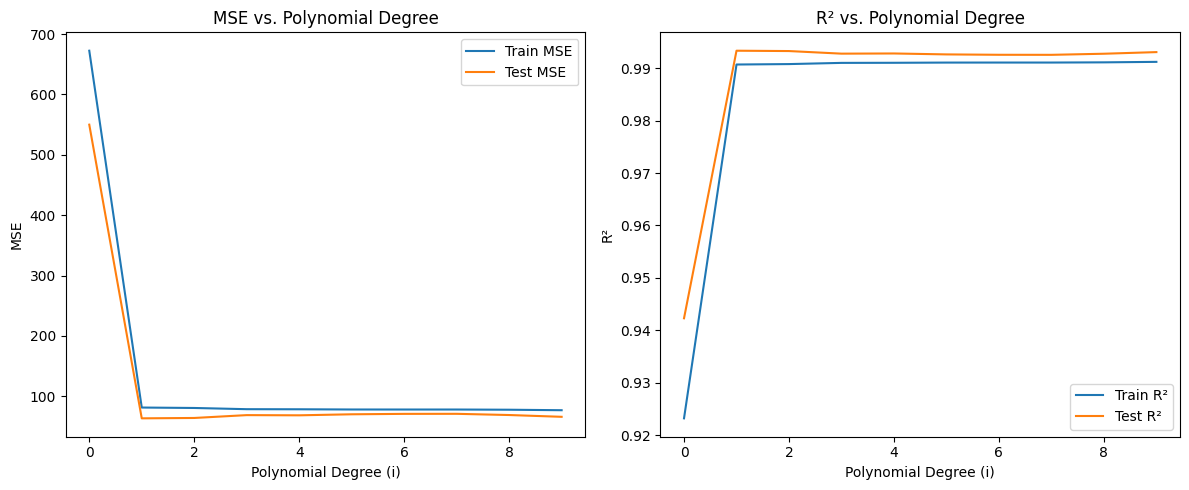

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Lists to store the metrics for plotting
mse_train_values = []
mse_test_values = []
r2_train_values = []
r2_test_values = []

for i in range(1,11):
  # Criando as features polinomiais
  poly = PolynomialFeatures(degree=i)
  X_poly_train = poly.fit_transform(X_train)
  X_poly_test = poly.transform(X_test)
  # Ajustando o modelo
  modelo = LinearRegression()
  modelo.fit(X_poly_train, y_train)
  # Fazendo previsões
  y_pred_train = modelo.predict(X_poly_train)
  y_pred_test = modelo.predict(X_poly_test)

  mse_train = mean_squared_error(y_train, y_pred_train)
  mse_test = mean_squared_error(y_test, y_pred_test)
  r2_train = r2_score(y_train, y_pred_train)
  r2_test = r2_score(y_test, y_pred_test)

  print(f"Degree {i}:")
  print(f"  Train MSE: {mse_train:.2f}, R²: {r2_train:.2f}")
  print(f"  Test MSE: {mse_test:.5f}, R²: {r2_test:.5f}")

  mse_train_values.append(mse_train)
  mse_test_values.append(mse_test)
  r2_train_values.append(r2_train)
  r2_test_values.append(r2_test)

# Plotting the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(10), mse_train_values, label="Train MSE")
plt.plot(range(10), mse_test_values, label="Test MSE")
plt.xlabel("Polynomial Degree (i)")
plt.ylabel("MSE")
plt.title("MSE vs. Polynomial Degree")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(10), r2_train_values, label="Train R²")
plt.plot(range(10), r2_test_values, label="Test R²")
plt.xlabel("Polynomial Degree (i)")
plt.ylabel("R²")
plt.title("R² vs. Polynomial Degree")
plt.legend()

plt.tight_layout()
plt.show()